**Synaptic biophysics** Day 2 morning

*Fast synapses in a "real" cell*

Based on the simulation from Neuromatch (Richard Naud): 
https://instructor.compneuro.neuromatch.io/tutorials/W2D3_BiologicalNeuronModels/instructor/W2D3_Tutorial3.html

In [1]:
# Imports
import matplotlib.pyplot as plt
import numpy as np

Plotting Functions

In [154]:
def my_illus_trains(pars, train, show=False):
  """
  Illustration of the spike train

  Args:
    pars  : parameters dictionary
    train : spike train
    show  : by default, make the graph but show later

  Returns:
    plot of spike train
  """
  plt.figure(figsize=(5, 9))
  plt.subplot(2,1,1)

  #from GPT5

  #eventplot takes a list of spike indices for train. Multiply by dt to convert to spike times
  positions = [list(np.nonzero(row)[0]*pars['dt']) for row in train]
    
  plt.eventplot(positions, color='g', lineoffsets = 1)
    
  plt.xlabel('Time (ms)')
  plt.ylabel('Spike train inputs')
  plt.xticks(np.arange(pars['range_t'][0], 1200, 200))

  if show:
    plt.show()

#print (help(my_illus_trains))

In [137]:
def my_illus_LIFSYN(pars, v_fmp, v, show=False):
  """
  Illustration of Free Membrane Potential (if there were no spikes, just the input) and membrane voltage with spikes

  Args:
    pars  : parameters dictionary
    v_fmp : free membrane potential, mV
    v     : membrane voltage, mV
    show  : by default, make the graph but show later

  Returns:
    plot of membrane voltage and free membrane potential (FMP), alongside with the spiking threshold
    and the mean FMP (dashed lines)
  """

  #plt.figure(figsize=(7, 5))
  plt.subplot(2,1,2)
  #plt.plot(pars['range_t'], v_fmp, 'r', lw=1.,
  #         label='Free mem. pot.', zorder=2)
  plt.plot(pars['range_t'], v, 'b', lw=1.,
           label='True mem. pot', zorder=1, alpha=0.7)
  
  plt.axhline(pars['V_th'], 0, 1, color='k', lw=2., ls='--',
              label='Spike Threshold', zorder=1)
  plt.axhline(np.mean(v_fmp), 0, 1, color='r', lw=2., ls='--',
              label='Mean Free Mem. Pot.', zorder=1)
  plt.xlabel('Time (ms)')
  plt.ylabel('V (mV)')
  plt.legend(loc=[.8, 0.68])
  
  if show:
    plt.show()

Generate spike trains according to Poisson (random) intervals

In [4]:
def Poisson_generator(pars, rate, n, myseed=False):
  """
  Generates poisson trains

  Args:
    pars       : parameter dictionary
    rate       : noise amplitute [Hz]
    n          : number of indepednent Poisson trains
    myseed     : random seed. int or Boolean

  Returns:
    pre_spike_train : spike train matrix, ith row represents whether
                      there is a spike in ith spike train over time
                      (1 if spike, 0 otherwise)
  """

  # Retrieve simulation parameters
  dt, range_t = pars['dt'], pars['range_t']
  Lt = range_t.size

  # set random seed
  if myseed:
      np.random.seed(seed=myseed)
  else:
      np.random.seed()

  # generate matrix of uniformly distributed random variables
  u_rand = np.random.rand(n, Lt)

  # generate Poisson train
  poisson_train = 1. * (u_rand < rate * (dt / 1000.))

  return poisson_train


Define the standard parameters of our LIF neuron.

In [85]:
def default_pars(**kwargs):
  pars = {}

  ### typical neuron parameters###
  pars['V_th'] = -50.    # spike threshold [mV] - was -55 mV
  pars['V_reset'] = -75. # reset potential [mV]
  pars['tau_m'] = 10    # membrane time constant [ms]
  pars['g_L'] = 10      # leak conductance [nS]
  pars['V_init'] = -65.  # initial potential [mV]
  pars['E_L'] = -75.     # leak reversal potential [mV]
  pars['tref'] = 2.      # refractory time (ms)

  ### simulation parameters ###
  pars['T'] = 400.  # Total duration of simulation [ms]
  pars['dt'] = .1   # Simulation time step [ms]

  ### overwrite with external parameters if any ###
  for k in kwargs:
    pars[k] = kwargs[k]

  pars['range_t'] = np.arange(0, pars['T'], pars['dt'])  # Vector of discretized time points [ms]

  return pars

Execute this cell to get a function for conductance-based LIF neuron (run_LIF_cond)

In [86]:
def run_LIF_cond(pars, I_inj, pre_spike_train):
  """
  Conductance-based LIF dynamics

  Args:
    pars               : parameter dictionary
    I_inj              : injected current [pA]. The injected current here
                         can be a value or an array
    pre_spike_train    : spike train input from presynaptic excitatory neurons
 

  Returns:
    rec_spikes         : spike times
    rec_v              : membrane potential
    gE                 : postsynaptic excitatory conductance

  """

  # Retrieve parameters
  V_th, V_reset = pars['V_th'], pars['V_reset']
  tau_m, g_L = pars['tau_m'], pars['g_L']
  V_init, E_L = pars['V_init'], pars['E_L']
  gE_bar = pars['gE_bar']
  VE = pars['VE']
  tau_syn_E = pars['tau_syn_E']
  tref = pars['tref']
  dt, range_t = pars['dt'], pars['range_t']
  Lt = range_t.size

  # Initialize
  tr = 0.
  v = np.zeros(Lt)
  v[0] = V_init
  gE = np.zeros(Lt)
  Iinj = I_inj * np.ones(Lt)  # ensure Iinj has length Lt

  if pre_spike_train.max() == 0:        #no spikes
    pre_spike_train_total = np.zeros(Lt)
  else:
    pre_spike_train_total = pre_spike_train.sum(axis=0) * np.ones(Lt)

  # simulation
  rec_spikes = []  # recording spike times
  for it in range(Lt - 1):
    if tr > 0:
      v[it] = V_reset
      tr = tr - 1
    elif v[it] >= V_th:  # reset voltage and record spike event
      rec_spikes.append(it)
      v[it] = V_reset
      tr = tref / dt    # number of timesteps until the refractory period is over

    # update the total synaptic conductance
    # for slow conductances this would need to be be more sophisticated

    # Euler Integration
    # 1st term = previous value
    # 2nd term = decrement according to decay time constant relative to timestep (Exponential decay)
    # 3rd term = instantaneous synaptic input if there are presynaptic spikes
    # it: iteration time
    gE[it + 1] = gE[it] - (dt / tau_syn_E) * gE[it] + gE_bar * pre_spike_train_total[it + 1]

    # dt/tau_syn_E: if that is small (small changes) then its a linear approximation

    # calculate the increment of the membrane potential (Euler integration) 
    # tau_m: membrane time constant
    # dv:  how to calculate the voltage change

    dv = (dt / tau_m) * (-(v[it] - E_L) - (gE[it + 1] / g_L) * (v[it] - VE) + Iinj[it] / g_L)

    # update membrane potential
    v[it+1] = v[it] + dv

  rec_spikes = np.array(rec_spikes) * dt

  return v, rec_spikes, gE


Main Code

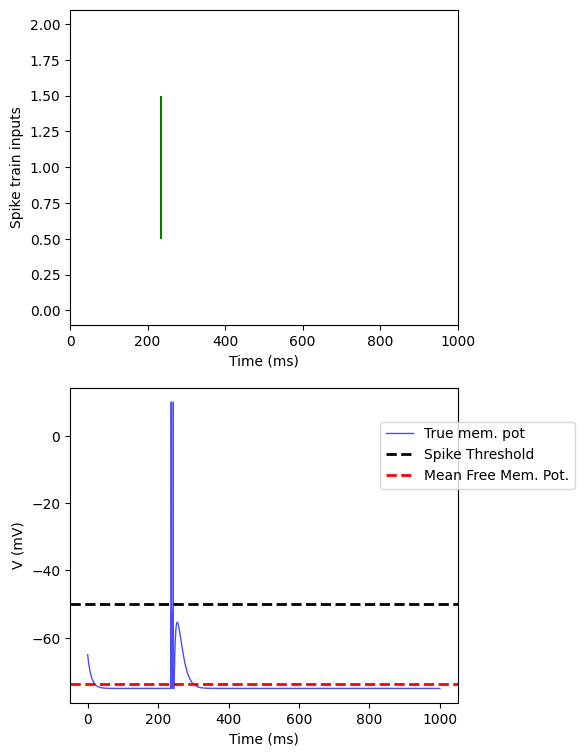

In [160]:
# Get default parameters
pars = default_pars(T=1000.)

# Add synaptic parameters
pars['gE_bar'] = 24       # [nS] mean conductance of one excitatory synapse. This was originally 2.4  ; 1 receptor is 25 pS
pars['VE'] = 0.          # [mV] excitatory reversal potential
pars['tau_syn_E'] = 10.  # [ms] slowish...classical AMPAR would be 5 ms 

pars['N_E'] = 1          # Number of excitatory synapses
pars['r_E'] = 1        # Mean rate of excitatory input [Hz], per synapse

# Generate presynaptic spike trains
pre_spike_train = Poisson_generator(pars, pars['r_E'], n=pars['N_E'])

# Simulate conductance-based LIF model
# no injected current
v, rec_spikes, gE = run_LIF_cond(pars, 0, pre_spike_train)

# Show spikes more clearly by setting voltage high
dt, range_t = pars['dt'], pars['range_t']
if rec_spikes.size:
  sp_num = (rec_spikes / dt).astype(int) - 1
  v[sp_num] = 10   # draw nicer spikes

# Temporarily remove the threshold to calculate V(t) without spikes (Free Membrane Potential, FMP)
original_V_th = pars['V_th'] 
pars['V_th'] = 1e3
v_fmp, _, _ = run_LIF_cond(pars, 0, pre_spike_train)

# reset to original threshold for display
pars['V_th'] = original_V_th

# plot train inputs (per synapse) as a separate graph
my_illus_trains(pars, pre_spike_train)

# plot neuron membrane voltage
my_illus_LIFSYN(pars, v_fmp, v)
